# improved Streat data analytics

## Scientifically grounded, causal SCG regression

This notebook implements the stated streaming protocol:

- use the first 20 minutes of the 100 Hz seismocardiogram (SCG) for development;
- emit one prediction per completed second for `S`, `D`, `H`, and `R` during the final 7 minutes;
- evaluate only after prediction with $100 - [MAE(S)+MAE(D)+MAE(H)+MAE(R)]$.

Version 2 separates the final holdout from model selection, uses only present/past sensor samples, reports missing-label coverage, and never uses clock minute or second as a predictor. The test labels are accessed only after the stream predictions have been created.

## Evidence behind the design

The feature set combines robust statistics with domain-specific morphology and spectral summaries:

- SCG contains cardiac and respiratory information; amplitude modulation, within-beat timing, and inter-beat timing are established respiratory features ([Pandia et al., 2012](https://doi.org/10.1088/0967-3334/33/10/1643)).
- Band-pass filtering is conventional for separating baseline/body motion from cardiac morphology in SCG ([Taebi et al., 2019](https://doi.org/10.3390/vibration2010005)).
- Envelope and spectral methods can estimate HR and RR from SCG ([Lin & Jhou, 2020](https://doi.org/10.1016/j.bspc.2019.101779)); VMD-based heartbeat envelopes provide a closely related decomposition approach ([Choudhary et al., 2018](https://doi.org/10.1109/WiSPNET.2018.8538723)).
- SCG peak morphology and timing carry cardiac-event information, but their annotation is noise-sensitive ([Shafiq et al., 2016](https://doi.org/10.1109/EMBC.2016.7591280)).
- SCG timing/morphology has demonstrated association with blood pressure, although rigorous BP estimation usually benefits from ECG timing and subject-specific calibration ([Zienkiewicz et al., 2024](https://doi.org/10.3390/bios14120621)).
- Temporal validation must preserve order; blocked or forward validation avoids training on the future ([Bergmeir & Benítez, 2012](https://doi.org/10.1016/j.ins.2011.12.028)).

VMD is not retained in the deployed pipeline because batch decomposition is less compatible with a one-second causal stream; causal Butterworth bands and trailing summaries are faster, deterministic, and directly deployable. Deep learning is also not justified by a single 20-minute labeled record; regularized and ensemble tabular models are compared instead.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.signal import butter, find_peaks, sosfilt, sosfilt_zi
from scipy.stats import kurtosis, skew
from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

FS = 100
TRAIN_SECONDS = 20 * 60
STREAM_SECONDS = 7 * 60
TARGETS = list("SDHR")
RANDOM_STATE = 42
START = pd.Timestamp("2020-11-13 12:19:00")
DATA_DIR = Path(".")

## 1. Load and align the data

The workbook contains formatting/formulas far below the real observations, so only the 1,749 documented label rows are read. Labels arrive irregularly at approximately 1 Hz and are averaged into one-second bins. The sensor file has 1,620 complete seconds plus one final sample; that incomplete second is excluded.

In [2]:
started = perf_counter()

sensor_values = pd.read_csv(DATA_DIR / "sensor-27minutes.csv", usecols=["Value"])["Value"]
sensor_seconds = sensor_values.iloc[:-1].to_numpy(dtype=float).reshape(-1, FS) * 0.001

label_rows = pd.read_excel(
    DATA_DIR / "label-27minutes.xlsx",
    nrows=1749,
    usecols=["Calculated time", "S", "D", "H", "R"],
)
label_rows.index = pd.Timestamp("2020-11-13") + pd.to_timedelta(
    label_rows.pop("Calculated time").astype(str)
)

timeline = pd.date_range(START, periods=len(sensor_seconds), freq="1s")
targets = label_rows.resample("1s").mean().reindex(timeline)

data_audit = pd.DataFrame(
    {
        "partition": ["development", "final stream"],
        "sensor seconds": [TRAIN_SECONDS, STREAM_SECONDS],
        "seconds with all labels": [
            targets.iloc[:TRAIN_SECONDS].notna().all(axis=1).sum(),
            targets.iloc[TRAIN_SECONDS:].notna().all(axis=1).sum(),
        ],
        "seconds with missing labels": [
            targets.iloc[:TRAIN_SECONDS].isna().any(axis=1).sum(),
            targets.iloc[TRAIN_SECONDS:].isna().any(axis=1).sum(),
        ],
    }
)

display(data_audit)
print(f"Loaded and aligned in {perf_counter() - started:.2f} seconds")

,partition,sensor seconds,seconds with all labels,seconds with missing labels
0,development,1200,1156,44
1,final stream,420,398,22


Loaded and aligned in 0.42 seconds


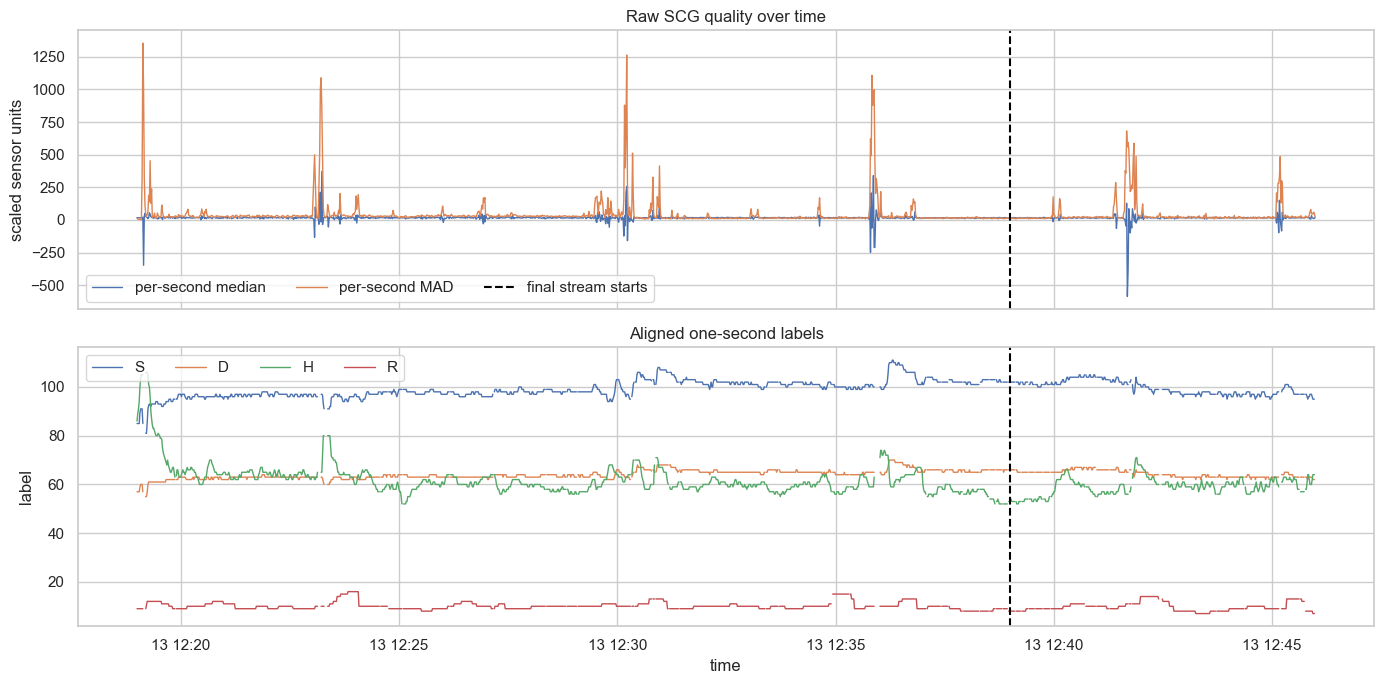

In [3]:
sensor_median = np.median(sensor_seconds, axis=1)
sensor_mad = np.median(np.abs(sensor_seconds - sensor_median[:, None]), axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(timeline, sensor_median, label="per-second median", linewidth=1)
axes[0].plot(timeline, sensor_mad, label="per-second MAD", linewidth=1)
axes[0].axvline(timeline[TRAIN_SECONDS], color="black", linestyle="--", label="final stream starts")
axes[0].set(title="Raw SCG quality over time", ylabel="scaled sensor units")
axes[0].legend(ncol=3)

for target in TARGETS:
    axes[1].plot(targets.index, targets[target], label=target, linewidth=1)
axes[1].axvline(timeline[TRAIN_SECONDS], color="black", linestyle="--")
axes[1].set(title="Aligned one-second labels", xlabel="time", ylabel="label")
axes[1].legend(ncol=4)
plt.tight_layout();

## 2. Causal, robust feature engineering

`SCGFeatureExtractor` learns its clipping limits from development samples only. Its filters are causal (`sosfilt`), all rolling windows are trailing, and every feature at second $t$ uses samples no later than the end of second $t$.

The features cover signal quality, robust amplitude, derivatives/line length, cardiac and morphology bands, spectral energy/entropy, peak prominence and spacing, 5–60 second summaries, a 10-second cardiac-rate estimate, and 60-second respiratory modulation estimates.

In [4]:
class SCGFeatureExtractor:
    def __init__(self, sample_rate=100, clip_mad=8, rolling_windows=(5, 15, 30, 60)):
        self.sample_rate = sample_rate
        self.clip_mad = clip_mad
        self.rolling_windows = rolling_windows

    def fit(self, seconds):
        values = np.asarray(seconds).ravel()
        self.center_ = np.median(values)
        self.scale_ = 1.4826 * np.median(np.abs(values - self.center_))
        return self

    def _bandpass(self, values, low, high):
        sos = butter(
            4,
            [low, high],
            btype="bandpass",
            fs=self.sample_rate,
            output="sos",
        )
        initial_state = sosfilt_zi(sos) * values[0]
        return sosfilt(sos, values, zi=initial_state)[0]

    def _statistics(self, name, values, output):
        quantiles = np.quantile(values, [0.10, 0.25, 0.50, 0.75, 0.90], axis=1)
        median = quantiles[2]
        output[f"{name}_mean"] = values.mean(axis=1)
        output[f"{name}_std"] = values.std(axis=1)
        output[f"{name}_median"] = median
        output[f"{name}_mad"] = np.median(np.abs(values - median[:, None]), axis=1)
        output[f"{name}_iqr"] = quantiles[3] - quantiles[1]
        output[f"{name}_q90_q10"] = quantiles[4] - quantiles[0]
        output[f"{name}_rms"] = np.sqrt(np.mean(values**2, axis=1))
        output[f"{name}_line_length"] = np.mean(np.abs(np.diff(values, axis=1)), axis=1)
        output[f"{name}_zcr"] = np.mean(
            np.diff(np.signbit(values - median[:, None]), axis=1), axis=1
        )
        output[f"{name}_skew"] = skew(values, axis=1, bias=False)
        output[f"{name}_kurtosis"] = kurtosis(values, axis=1, bias=False)

    def _spectral_features(self, name, values, output):
        frequencies = np.fft.rfftfreq(self.sample_rate, 1 / self.sample_rate)
        centered = values - values.mean(axis=1, keepdims=True)
        power = np.abs(np.fft.rfft(centered, axis=1)) ** 2
        total_power = power[:, 1:].sum(axis=1) + 1e-12

        for low, high in [(1, 2), (2, 4), (4, 8), (8, 15), (15, 30)]:
            band = (frequencies >= low) & (frequencies < high)
            band_power = power[:, band].sum(axis=1)
            output[f"{name}_logpower_{low}_{high}"] = np.log1p(band_power)
            output[f"{name}_relpower_{low}_{high}"] = band_power / total_power

        band = (frequencies >= 1) & (frequencies <= 30)
        output[f"{name}_dominant_hz"] = frequencies[band][
            np.argmax(power[:, band], axis=1)
        ]
        probabilities = power[:, band] / (power[:, band].sum(axis=1, keepdims=True) + 1e-12)
        output[f"{name}_spectral_entropy"] = -(
            probabilities * np.log(probabilities + 1e-12)
        ).sum(axis=1) / np.log(probabilities.shape[1])

    def _peak_features(self, morphology):
        counts, prominences, intervals = [], [], []
        for second in morphology:
            peaks, properties = find_peaks(
                np.abs(second),
                distance=18,
                prominence=np.std(second) * 0.35,
            )
            counts.append(len(peaks))
            prominences.append(np.median(properties["prominences"]) if len(peaks) else 0)
            intervals.append(
                np.median(np.diff(peaks)) / self.sample_rate if len(peaks) > 1 else 0
            )
        return counts, prominences, intervals

    def _heart_rate_features(self, heart_signal):
        fft_rates, autocorrelation_rates = [], []
        flattened = heart_signal.ravel()

        for second_index in range(len(heart_signal)):
            start = max(0, (second_index + 1 - 10) * self.sample_rate)
            values = flattened[start : (second_index + 1) * self.sample_rate]
            values = values - values.mean()
            frequencies = np.fft.rfftfreq(len(values), 1 / self.sample_rate)
            power = np.abs(np.fft.rfft(values)) ** 2
            heart_band = (frequencies >= 0.65) & (frequencies <= 2.5)
            fft_rates.append(
                frequencies[heart_band][np.argmax(power[heart_band])] * 60
            )

            autocorrelation = np.correlate(values, values, mode="full")[len(values) - 1 :]
            autocorrelation = autocorrelation / (autocorrelation[0] + 1e-12)
            low_lag = int(self.sample_rate / 2.5)
            high_lag = int(self.sample_rate / 0.65)
            peaks, _ = find_peaks(autocorrelation[low_lag : high_lag + 1])
            if len(peaks):
                lag = low_lag + peaks[
                    np.argmax(autocorrelation[low_lag + peaks])
                ]
            else:
                lag = low_lag + np.argmax(
                    autocorrelation[low_lag : high_lag + 1]
                )
            autocorrelation_rates.append(60 * self.sample_rate / lag)

        return fft_rates, autocorrelation_rates

    def _respiratory_rate(self, values):
        rates = []
        for second_index in range(len(values)):
            window = values[max(0, second_index + 1 - 60) : second_index + 1]
            window = window - window.mean()
            if len(window) < 10:
                rates.append(12.0)
                continue
            frequencies = np.fft.rfftfreq(len(window), 1.0)
            power = np.abs(np.fft.rfft(window)) ** 2
            respiratory_band = (frequencies >= 0.10) & (frequencies <= 0.40)
            rates.append(
                frequencies[respiratory_band][
                    np.argmax(power[respiratory_band])
                ]
                * 60
            )
        return rates

    def transform(self, seconds):
        raw = np.asarray(seconds)
        low = self.center_ - self.clip_mad * self.scale_
        high = self.center_ + self.clip_mad * self.scale_
        clean_flat = np.clip(raw.ravel(), low, high)
        clean = clean_flat.reshape(-1, self.sample_rate)
        heart = self._bandpass(clean_flat, 0.7, 4.0).reshape(-1, self.sample_rate)
        morphology = self._bandpass(clean_flat, 4.0, 30.0).reshape(-1, self.sample_rate)

        output = {}
        for name, values in [("clean", clean), ("heart", heart), ("morph", morphology)]:
            self._statistics(name, values, output)
            self._spectral_features(name, values, output)

        output["artifact_fraction"] = np.mean((raw < low) | (raw > high), axis=1)
        output["raw_median"] = np.median(raw, axis=1)
        output["raw_mad"] = np.median(
            np.abs(raw - np.median(raw, axis=1)[:, None]), axis=1
        )
        (
            output["peak_count"],
            output["peak_prominence"],
            output["peak_interval"],
        ) = self._peak_features(morphology)

        features = pd.DataFrame(output)
        rolling_columns = [
            "clean_median",
            "clean_mad",
            "clean_rms",
            "clean_line_length",
            "heart_rms",
            "heart_line_length",
            "morph_rms",
            "morph_line_length",
            "morph_logpower_4_8",
            "morph_logpower_8_15",
            "heart_logpower_1_2",
            "heart_logpower_2_4",
            "peak_count",
            "peak_prominence",
            "artifact_fraction",
        ]

        for window in self.rolling_windows:
            rolling = features[rolling_columns].rolling(window, min_periods=1)
            features = pd.concat(
                [
                    features,
                    rolling.mean().add_suffix(f"_mean_{window}s"),
                    rolling.std(ddof=0).add_suffix(f"_std_{window}s"),
                ],
                axis=1,
            )

        (
            features["heart_rate_fft"],
            features["heart_rate_autocorr"],
        ) = self._heart_rate_features(heart)
        features["morph_rms_resp_rate"] = self._respiratory_rate(
            features["morph_rms"].to_numpy()
        )
        features["clean_median_resp_rate"] = self._respiratory_rate(
            features["clean_median"].to_numpy()
        )
        features.index = timeline[: len(features)]
        return features


feature_extractor = SCGFeatureExtractor(sample_rate=FS).fit(
    sensor_seconds[:TRAIN_SECONDS]
)
feature_started = perf_counter()
features = feature_extractor.transform(sensor_seconds)

print(f"Created {features.shape[1]} causal features for {features.shape[0]} seconds")
print(f"Feature extraction time: {perf_counter() - feature_started:.2f} seconds")
print("Clock-derived features:", [name for name in features if name in {"minute", "second", "elapsed_seconds"}])

Created 199 causal features for 1620 seconds
Feature extraction time: 0.81 seconds
Clock-derived features: []


## 3. Training-only, expanding-window model selection

Three 200-second validation windows end at seconds 800, 1,000, and 1,200. Each model sees only observations earlier than its validation window. The fixed median is shown as a diagnostic baseline but is ineligible under the project rule against trivial fixed-output solutions.

Model selection uses the sum of target MAEs because that is exactly the official scoring loss. The candidate set is intentionally compact relative to 1,156 fully labeled development seconds.

In [5]:
valid_development = targets.iloc[:TRAIN_SECONDS].notna().all(axis=1).to_numpy()
development_second_numbers = np.flatnonzero(valid_development)
X_development = features.iloc[:TRAIN_SECONDS].loc[valid_development].reset_index(drop=True)
y_development = targets.iloc[:TRAIN_SECONDS].loc[valid_development].reset_index(drop=True)

folds = [
    (
        np.flatnonzero(development_second_numbers < fold_end - 200),
        np.flatnonzero(
            (development_second_numbers >= fold_end - 200)
            & (development_second_numbers < fold_end)
        ),
    )
    for fold_end in [800, 1000, 1200]
]

model_specs = {
    "Ridge (alpha=100)": make_pipeline(StandardScaler(), Ridge(alpha=100.0)),
    "PLS (8 components)": PLSRegression(n_components=8, scale=True, max_iter=1000),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=350,
        min_samples_leaf=5,
        max_features=0.7,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=350,
        min_samples_leaf=5,
        max_features=0.7,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Histogram Gradient Boosting": MultiOutputRegressor(
        HistGradientBoostingRegressor(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=3,
            random_state=RANDOM_STATE,
        ),
        n_jobs=-1,
    ),
}

validation_rows = []
baseline_fold_maes = []
for train_rows, validation_rows_index in folds:
    prediction = np.tile(
        np.median(y_development.iloc[train_rows], axis=0),
        (len(validation_rows_index), 1),
    )
    baseline_fold_maes.append(
        mean_absolute_error(
            y_development.iloc[validation_rows_index],
            prediction,
            multioutput="raw_values",
        )
    )

baseline_mae = np.mean(baseline_fold_maes, axis=0)
validation_rows.append(
    {
        "model": "Median baseline (ineligible)",
        "eligible": False,
        **dict(zip(TARGETS, baseline_mae)),
        "sum_MAE": baseline_mae.sum(),
        "validation_score": 100 - baseline_mae.sum(),
        "fold_score_SD": np.std(100 - np.sum(baseline_fold_maes, axis=1)),
    }
)

selection_started = perf_counter()
for model_number, (name, model) in enumerate(model_specs.items(), start=1):
    fold_maes = []
    for train_rows, validation_rows_index in folds:
        fitted = clone(model).fit(
            X_development.iloc[train_rows], y_development.iloc[train_rows]
        )
        fold_maes.append(
            mean_absolute_error(
                y_development.iloc[validation_rows_index],
                fitted.predict(X_development.iloc[validation_rows_index]),
                multioutput="raw_values",
            )
        )

    mean_mae = np.mean(fold_maes, axis=0)
    fold_scores = 100 - np.sum(fold_maes, axis=1)
    validation_rows.append(
        {
            "model": name,
            "eligible": True,
            **dict(zip(TARGETS, mean_mae)),
            "sum_MAE": mean_mae.sum(),
            "validation_score": 100 - mean_mae.sum(),
            "fold_score_SD": fold_scores.std(),
        }
    )
    elapsed = perf_counter() - selection_started
    remaining = elapsed / model_number * (len(model_specs) - model_number)
    print(
        f"{model_number}/{len(model_specs)} {name}: "
        f"score={100 - mean_mae.sum():.3f}, elapsed={elapsed:.1f}s, ETA={remaining:.1f}s"
    )

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values("validation_score", ascending=False)
    .reset_index(drop=True)
)
display(validation_results.round(3))

selected_name = validation_results.loc[validation_results["eligible"], "model"].iloc[0]
selected_model = clone(model_specs[selected_name])
print(f"Selected without consulting the final 7 minutes: {selected_name}")

1/5 Ridge (alpha=100): score=90.078, elapsed=0.0s, ETA=0.2s
2/5 PLS (8 components): score=89.866, elapsed=0.1s, ETA=0.2s


3/5 Extra Trees: score=89.103, elapsed=2.6s, ETA=1.8s


4/5 Random Forest: score=86.204, elapsed=13.9s, ETA=3.5s


5/5 Histogram Gradient Boosting: score=85.743, elapsed=35.3s, ETA=0.0s


,model,eligible,S,D,H,R,sum_MAE,validation_score,fold_score_SD
0,Ridge (alpha=100),True,3.143,1.695,3.733,1.351,9.922,90.078,4.437
1,PLS (8 components),True,3.329,1.673,3.805,1.327,10.134,89.866,4.236
2,Extra Trees,True,3.678,1.858,4.299,1.063,10.897,89.103,4.880
3,Median baseline (ineligible),False,4.514,2.394,3.651,0.950,11.509,88.491,1.779
4,Random Forest,True,4.106,2.084,6.433,1.172,13.796,86.204,5.807
5,Histogram Gradient Boosting,True,4.372,2.259,6.421,1.205,14.257,85.743,6.777


Selected without consulting the final 7 minutes: Ridge (alpha=100)


## 4. Fit once, then simulate the final seven-minute stream

The selected estimator is fit on every available development label. Predictions are then emitted in chronological order from the precomputed causal feature row for each completed second. No stream label is supplied to the estimator or feature extractor.

In [6]:
selected_model.fit(X_development, y_development)

stream_predictions = []
stream_started = perf_counter()

for completed, second_number in enumerate(
    range(TRAIN_SECONDS, TRAIN_SECONDS + STREAM_SECONDS), start=1
):
    stream_predictions.append(
        selected_model.predict(features.iloc[[second_number]])[0]
    )
    if completed % 60 == 0 or completed == STREAM_SECONDS:
        elapsed = perf_counter() - stream_started
        remaining = elapsed / completed * (STREAM_SECONDS - completed)
        print(
            f"Predicted {completed:3d}/{STREAM_SECONDS} seconds; "
            f"elapsed={elapsed:.2f}s; ETA={remaining:.2f}s"
        )

predictions = pd.DataFrame(
    stream_predictions,
    index=timeline[TRAIN_SECONDS:],
    columns=TARGETS,
)

print(f"All stream predictions completed in {perf_counter() - stream_started:.2f} seconds")
display(predictions.head())

Predicted  60/420 seconds; elapsed=0.12s; ETA=0.73s


Predicted 120/420 seconds; elapsed=0.25s; ETA=0.62s


Predicted 180/420 seconds; elapsed=0.38s; ETA=0.51s


Predicted 240/420 seconds; elapsed=0.51s; ETA=0.38s


Predicted 300/420 seconds; elapsed=0.63s; ETA=0.25s


Predicted 360/420 seconds; elapsed=0.76s; ETA=0.13s


Predicted 420/420 seconds; elapsed=0.88s; ETA=0.00s
All stream predictions completed in 0.88 seconds


,S,D,H,R
2020-11-13 12:39:00,101.822162,65.337239,55.690798,8.301698
2020-11-13 12:39:01,102.252112,65.670778,55.950277,8.607934
2020-11-13 12:39:02,102.745023,65.898292,55.659589,8.550270
2020-11-13 12:39:03,102.278632,65.528165,55.689051,8.452283
2020-11-13 12:39:04,102.474153,65.665485,55.569538,8.514975


## 5. Final holdout evaluation

Evaluation begins only now. Missing reference labels are reported and excluded symmetrically from all four target MAEs. A moving-block bootstrap supplies uncertainty while retaining short-range temporal dependence.

In [7]:
stream_targets = targets.iloc[TRAIN_SECONDS:]
scored_seconds = stream_targets.notna().all(axis=1)
errors = (predictions.loc[scored_seconds] - stream_targets.loc[scored_seconds]).abs()
test_mae = errors.mean()
test_score = 100 - test_mae.sum()

test_results = pd.DataFrame(
    {
        "MAE": test_mae,
        "available labels": scored_seconds.sum(),
        "total stream seconds": len(scored_seconds),
    }
)
display(test_results.round(3))
print(f"Final Version 2 score: {test_score:.3f} / 100")
print(f"Evaluation coverage: {scored_seconds.sum()} / {len(scored_seconds)} seconds ({scored_seconds.mean():.1%})")

,MAE,available labels,total stream seconds
S,2.364,398,420
D,1.200,398,420
H,5.164,398,420
R,1.532,398,420


Final Version 2 score: 89.740 / 100
Evaluation coverage: 398 / 420 seconds (94.8%)


In [8]:
def moving_block_bootstrap(error_frame, block_size=10, repetitions=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    values = error_frame.to_numpy()
    sample_size = len(values)
    blocks_per_sample = int(np.ceil(sample_size / block_size))
    bootstrap_maes = []

    for _ in range(repetitions):
        starts = rng.integers(0, sample_size - block_size + 1, size=blocks_per_sample)
        sample = np.concatenate(
            [values[start : start + block_size] for start in starts], axis=0
        )[:sample_size]
        bootstrap_maes.append(sample.mean(axis=0))

    bootstrap_maes = np.asarray(bootstrap_maes)
    return bootstrap_maes


bootstrap_maes = moving_block_bootstrap(errors)
mae_intervals = pd.DataFrame(
    {
        "MAE": test_mae,
        "95% lower": np.quantile(bootstrap_maes, 0.025, axis=0),
        "95% upper": np.quantile(bootstrap_maes, 0.975, axis=0),
    },
    index=TARGETS,
)
bootstrap_scores = 100 - bootstrap_maes.sum(axis=1)

display(mae_intervals.round(3))
print(
    "95% moving-block bootstrap interval for the score: "
    f"[{np.quantile(bootstrap_scores, 0.025):.3f}, "
    f"{np.quantile(bootstrap_scores, 0.975):.3f}]"
)

,MAE,95% lower,95% upper
S,2.364,2.031,2.752
D,1.200,1.040,1.370
H,5.164,4.483,6.045
R,1.532,1.211,1.855


95% moving-block bootstrap interval for the score: [88.412, 90.906]


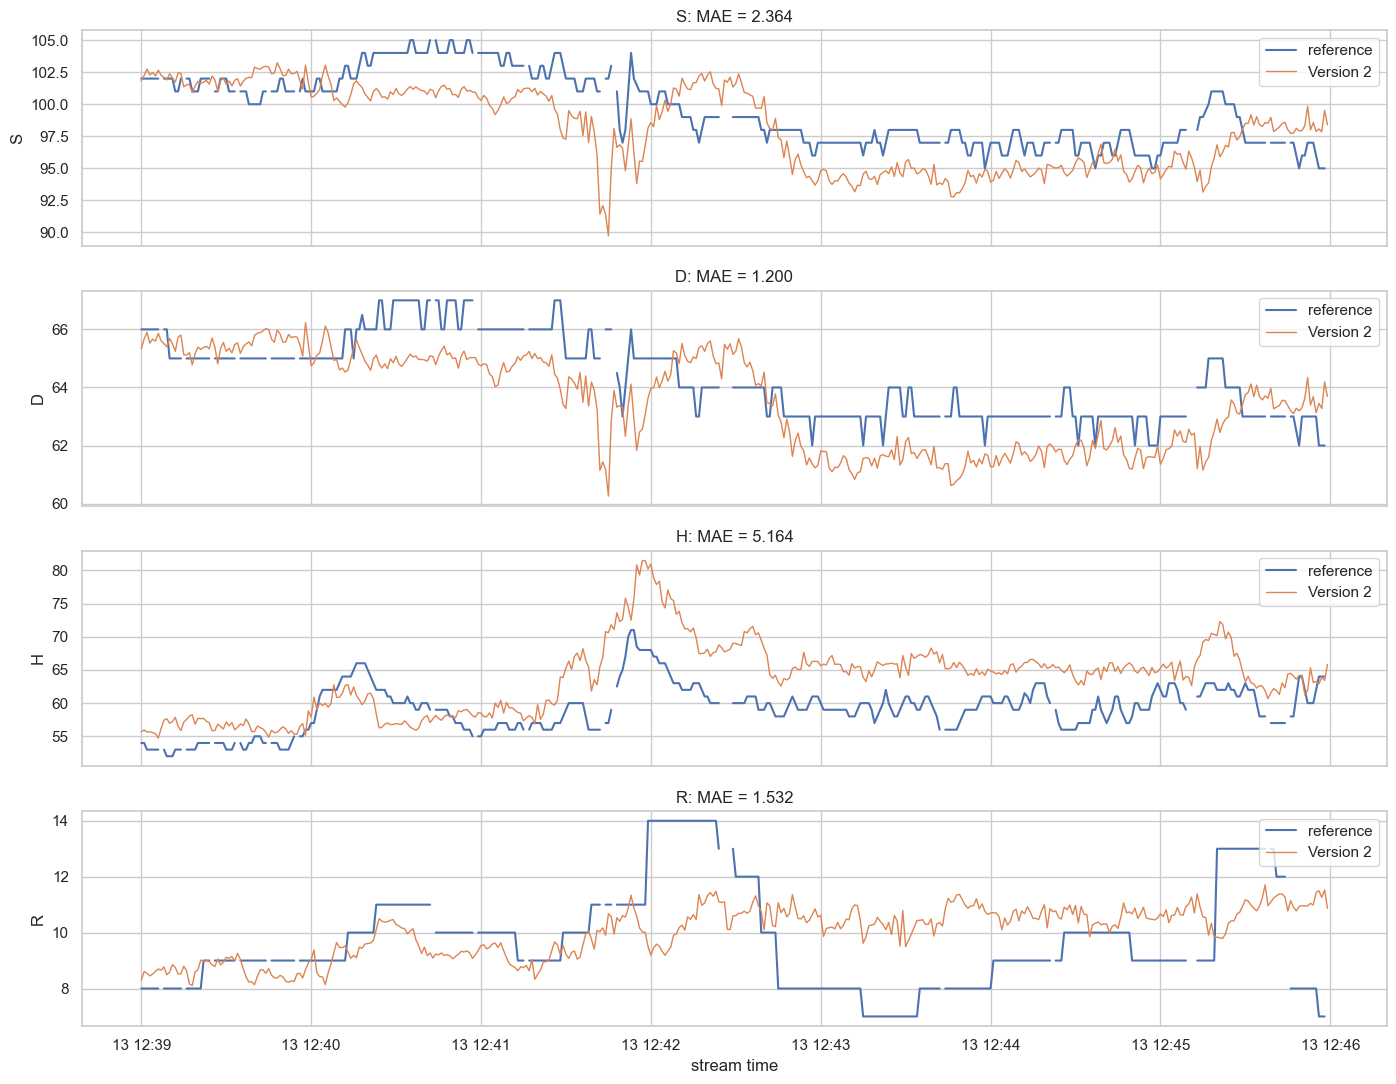

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
for axis, target in zip(axes, TARGETS):
    axis.plot(stream_targets.index, stream_targets[target], label="reference", linewidth=1.5)
    axis.plot(predictions.index, predictions[target], label="Version 2", linewidth=1)
    axis.set(ylabel=target, title=f"{target}: MAE = {test_mae[target]:.3f}")
    axis.legend(loc="upper right")
axes[-1].set_xlabel("stream time")
plt.tight_layout();

## 6. Interpret the regularized model

The selected ridge pipeline is transparent: after feature standardization, coefficient magnitude gives a useful within-target ranking. This is descriptive rather than causal importance; correlated rolling features can share weight.

In [10]:
ridge = selected_model.named_steps["ridge"]
coefficient_rows = []
for target_number, target in enumerate(TARGETS):
    top = np.argsort(np.abs(ridge.coef_[target_number]))[-8:][::-1]
    for rank, feature_number in enumerate(top, start=1):
        coefficient_rows.append(
            {
                "target": target,
                "rank": rank,
                "feature": features.columns[feature_number],
                "standardized coefficient": ridge.coef_[target_number, feature_number],
            }
        )

coefficient_table = pd.DataFrame(coefficient_rows)
display(coefficient_table.round(4))

,target,rank,feature,standardized coefficient
0,S,1,heart_line_length_mean_60s,1.0994
1,S,2,morph_logpower_8_15_mean_60s,-1.0902
2,S,3,morph_logpower_8_15_mean_30s,-0.8066
3,S,4,peak_count_std_60s,0.6668
4,S,5,heart_line_length_std_60s,0.6052
5,S,6,morph_logpower_8_15_std_60s,0.5993
6,S,7,morph_logpower_4_8_std_60s,-0.5619
7,S,8,heart_line_length_mean_30s,0.5463
8,D,1,heart_line_length_mean_60s,0.5515
9,D,2,morph_logpower_8_15_mean_60s,-0.5248


## 7. Conclusions and limits

Version 2 is a cleaner scientific baseline: all feature operations are causal, artifacts are clipped using development-only statistics, model choice is made with expanding windows, the final stream is touched once, and coverage plus uncertainty are explicit.

The result must not be interpreted as clinical validation. There is only one short recording, no subject-level split, no external cohort, and irregular/missing reference labels. `S` and `D` appear to be blood-pressure-like quantities, but the file provides no data dictionary, units, sensor orientation, subject metadata, or calibration protocol. The next scientifically meaningful step is not a larger neural network; it is collecting multiple labeled subjects/sessions and evaluating with leave-subject/session-out validation. ECG or PPG timing would also enable physiologically better grounded BP features such as PEP or pulse transit/arrival time.